---
## 1. Why CNMFe?

In **2-photon** microscopy the laser excites only a thin focal plane: every pixel records signal from one or two neurons at most, and background fluorescence is small.

In **1-photon** miniscope microscopy the entire tissue depth fluoresces. Every pixel records:
- the in-focus neurons it sits on, plus
- a large diffuse background from out-of-focus neuropil and scattering — spatially smooth, temporally drift-correlated, often larger in amplitude than individual transients.

Standard CNMF treats pixels independently and fits the structured background with spurious neural components. **CNMFe** adds a **ring-model background** (predict each pixel from a ring of neighbours) so the background is removed before running NMF on the residual.

Below we generate a synthetic 1p movie with known ground truth so we can verify every step.

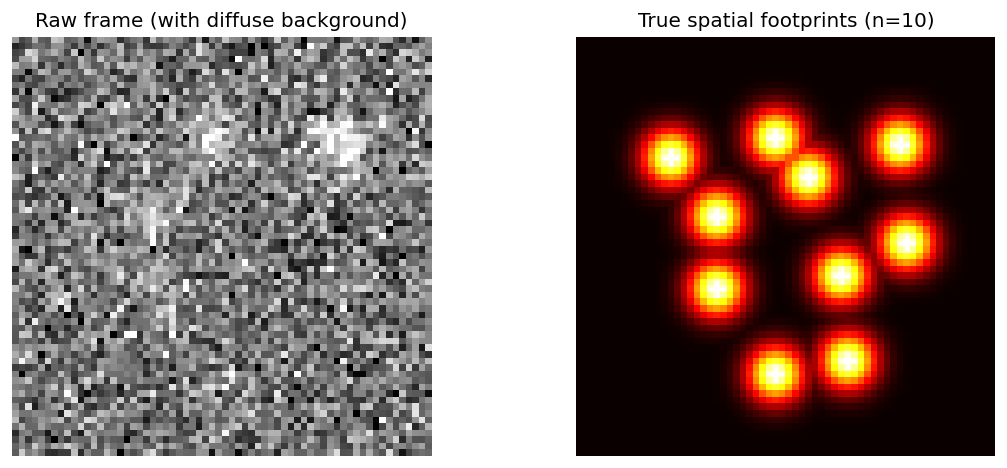

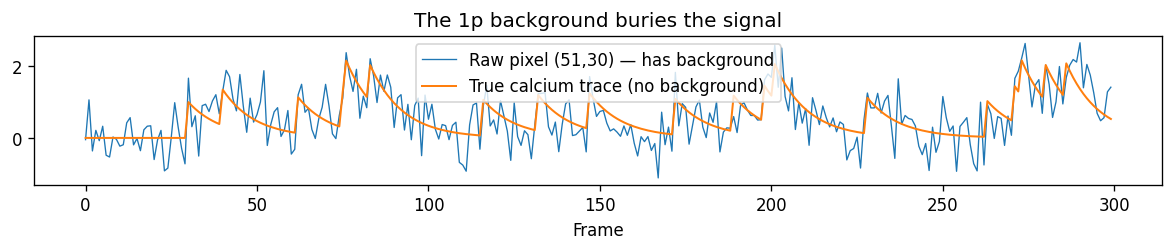

In [3]:
# --- A raw frame, the true footprints, and a raw pixel trace ---------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(movie[100], cmap='gray',
               vmin=np.percentile(movie, 1), vmax=np.percentile(movie, 99))
axes[0].set_title('Raw frame (with diffuse background)'); axes[0].axis('off')

axes[1].imshow(A_true.max(axis=1).reshape(H, W), cmap='hot')
for r, c in centers:
    axes[1].plot(c, r, 'w+', ms=10, mew=2)
axes[1].set_title(f'True spatial footprints (n={K})'); axes[1].axis('off')
plt.tight_layout(); plt.show()

# A raw pixel trace at one neuron's centre vs the underlying calcium trace
r0, c0 = centers[0]
raw_trace = movie[:, r0, c0]
fig, ax = plt.subplots(figsize=(10, 2.2))
ax.plot(raw_trace, lw=0.8, label=f'Raw pixel ({r0},{c0}) — has background')
ax.plot(C_true[0], lw=1.2, label='True calcium trace (no background)')
ax.set_xlabel('Frame'); ax.legend()
ax.set_title('The 1p background buries the signal')
plt.tight_layout(); plt.show()

In [4]:
from minicnmfe.io import save_zarr

tmpdir = tempfile.mkdtemp()
zarr_path = os.path.join(tmpdir, 'movie.zarr')
z = save_zarr(movie, zarr_path, chunk_t=100)
print(f'zarr shape  : {z.shape}')
print(f'zarr chunks : {z.chunks}    (only the chunk containing the requested frame is read)')
print(f'zarr dtype  : {z.dtype}')

frame_50 = z[50]
print(f'Single frame access: shape={frame_50.shape}  (no full movie loaded)')

zarr shape  : (300, 64, 64)
zarr chunks : (100, 64, 64)    (only the chunk containing the requested frame is read)
zarr dtype  : float32
Single frame access: shape=(64, 64)  (no full movie loaded)


True drift          : [ 3.7 -2.1]
Detected correction : [-3.7  2.1]   (should equal -true_drift)
Subpixel error      : 0.000 px


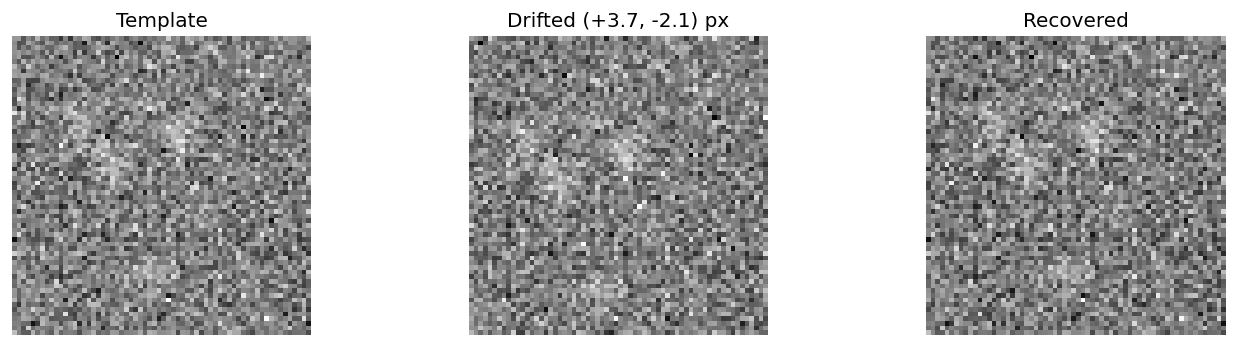

In [5]:
from minicnmfe.motion_correction import estimate_shifts, apply_shift, motion_correct

# Single-frame demo: apply a known shift, then recover it.
frame = movie[50].copy()
true_drift = np.array([3.7, -2.1], dtype=np.float32)
drifted = apply_shift(frame, true_drift)
correction = estimate_shifts(drifted, frame, upsample_factor=20)

print(f'True drift          : {true_drift}')
print(f'Detected correction : {correction}   (should equal -true_drift)')
print(f'Subpixel error      : {np.abs(correction + true_drift).max():.3f} px')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(frame, cmap='gray');    axes[0].set_title('Template'); axes[0].axis('off')
axes[1].imshow(drifted, cmap='gray');  axes[1].set_title(f'Drifted ({true_drift[0]:+.1f}, {true_drift[1]:+.1f}) px'); axes[1].axis('off')
axes[2].imshow(apply_shift(drifted, correction), cmap='gray')
axes[2].set_title('Recovered'); axes[2].axis('off')
plt.tight_layout(); plt.show()

---
## 4. CORR and PNR summary images

We need to know **where** the neurons are before we can extract them. Two complementary statistics:

- **CORR**: at each pixel, the mean Pearson correlation with its 8 neighbours over time. Neurons span several pixels that flash together → high CORR.
- **PNR**: peak-to-noise ratio — the maximum fluorescence deviation divided by the noise std. Neurons produce flashes much larger than baseline noise → high PNR.

Multiplying `CORR × PNR` gives a clean seed-score map: noisy pixels with high apparent correlation by chance get masked because their PNR is low; bright artefacts with high PNR get masked because their CORR is low.

A **center-surround** spatial filter (DoG-like, sums to zero) is applied before computing CORR/PNR to suppress the diffuse background while preserving signals at the neuron scale.

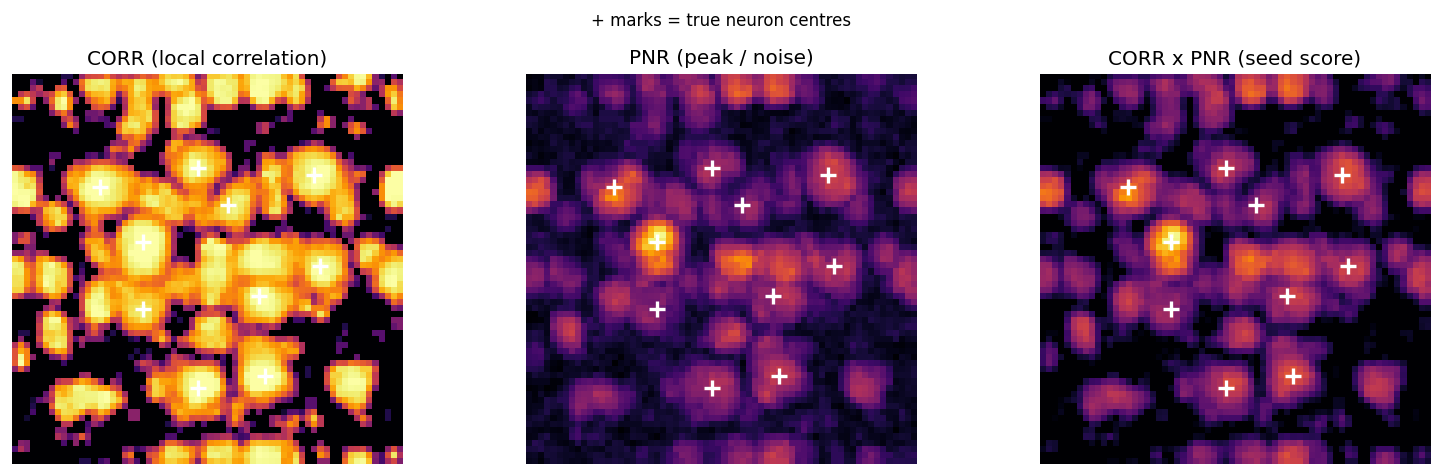

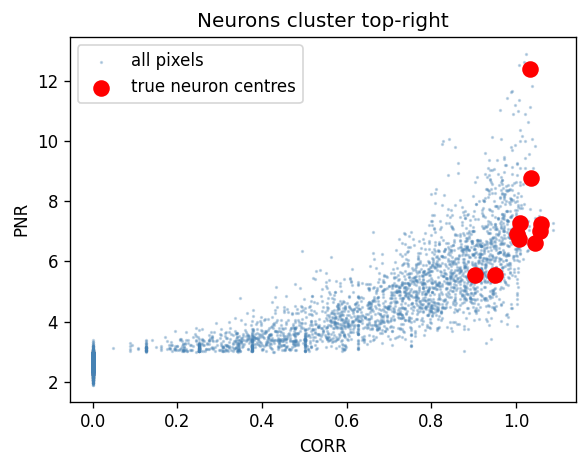

In [8]:
# Compute CORR and PNR images on the (PSF-filtered) movie
cn, pnr = correlation_pnr(mc_movie, sigma=sigma, center_psf=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(cn, cmap='inferno', vmin=0, vmax=1)
axes[1].imshow(pnr, cmap='inferno')
axes[2].imshow(cn * pnr, cmap='inferno')
for ax, title in zip(axes, ['CORR (local correlation)', 'PNR (peak / noise)', 'CORR x PNR (seed score)']):
    for r, c in centers:
        ax.plot(c, r, 'w+', ms=10, mew=2)
    ax.set_title(title); ax.axis('off')
plt.suptitle('+ marks = true neuron centres', fontsize=10)
plt.tight_layout(); plt.show()

# Scatter — neurons cluster in the high-CORR / high-PNR region
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(cn.ravel(), pnr.ravel(), s=1, alpha=0.3, c='steelblue', label='all pixels')
ax.scatter(cn[centers[:, 0], centers[:, 1]], pnr[centers[:, 0], centers[:, 1]],
           s=80, c='red', zorder=5, label='true neuron centres')
ax.set_xlabel('CORR'); ax.set_ylabel('PNR'); ax.legend()
ax.set_title('Neurons cluster top-right')
plt.tight_layout(); plt.show()

Ring radius: 10.5 px


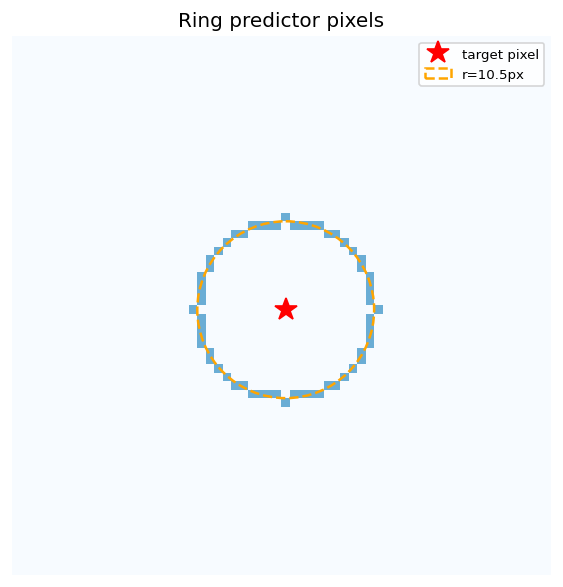

In [9]:
from minicnmfe.background import build_ring_indices, compute_W, subtract_background
from minicnmfe._utils import make_2d

ring_radius = 1.5 * (2 * sigma + 1)
print(f'Ring radius: {ring_radius:.1f} px')

# Visualise the ring of one pixel
rings = build_ring_indices((H, W), ring_radius)
centre_pixel = (H // 2) * W + (W // 2)
ring_mask = np.zeros(H * W, dtype=bool)
ring_mask[rings[centre_pixel]] = True

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(ring_mask.reshape(H, W).astype(float), cmap='Blues', vmin=0, vmax=2)
ax.plot(W // 2, H // 2, 'r*', ms=14, label='target pixel')
ax.add_patch(plt.Circle((W // 2, H // 2), ring_radius, fill=False,
             color='orange', lw=1.5, ls='--', label=f'r={ring_radius:.1f}px'))
ax.legend(fontsize=8); ax.set_title('Ring predictor pixels'); ax.axis('off')
plt.tight_layout(); plt.show()

---
## 6. Greedy initialization

Find neurons one at a time, brightest first:

1. Pick the pixel with the highest `CORR × PNR`.
2. Extract the neuron's footprint and trace from a small patch around it (3-component OLS: trace, local background, baseline).
3. Deconvolve the trace with OASIS (clean AR(1) shape).
4. Subtract `a_i * c_i` from the data.
5. Recompute `CORR × PNR` locally; suppress a disk of radius `~2σ` around every found centre so the residual halo of one neuron can't seed the next.
6. Repeat until no pixel passes the threshold.

Greedy works well because we always remove the strongest neuron first — easy cases never interfere with hard ones.

Initialized 20 components (truth = 10)


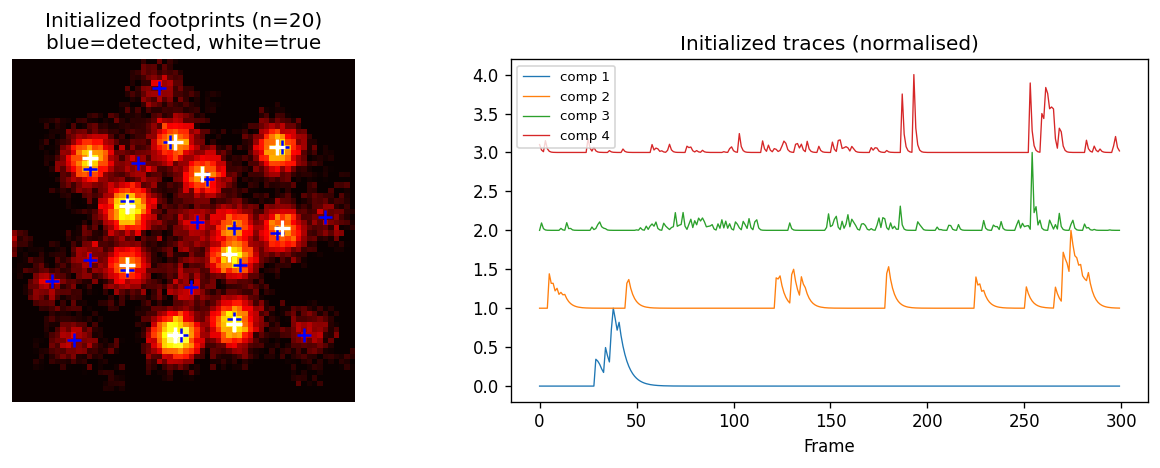

In [12]:
A_init, C_init, C_raw_init, centers_init = greedy_corr_pnr(
    mc_movie, sigma=sigma, min_corr=0.8, min_pnr=6.0, ar_order=1, border_px=5
)
K_init = A_init.shape[1]
print(f'Initialized {K_init} components (truth = {K})')

A_init_dense = np.asarray(A_init.todense()).reshape(H, W, K_init)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(A_init_dense.max(axis=2), cmap='hot')
for r, c in centers_init: axes[0].plot(c, r, 'b+', ms=8, mew=1.5)
for r, c in centers:        axes[0].plot(c, r, 'w+', ms=10, mew=2)
axes[0].set_title(f'Initialized footprints (n={K_init})\nblue=detected, white=true')
axes[0].axis('off')

for k in range(min(4, K_init)):
    axes[1].plot(C_init[k] / (C_init[k].max() + 1e-10) + k, lw=0.8, label=f'comp {k+1}')
axes[1].set_xlabel('Frame'); axes[1].set_title('Initialized traces (normalised)')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Estimated g = 0.791   (true g = 0.900)
Estimated sn = 0.021


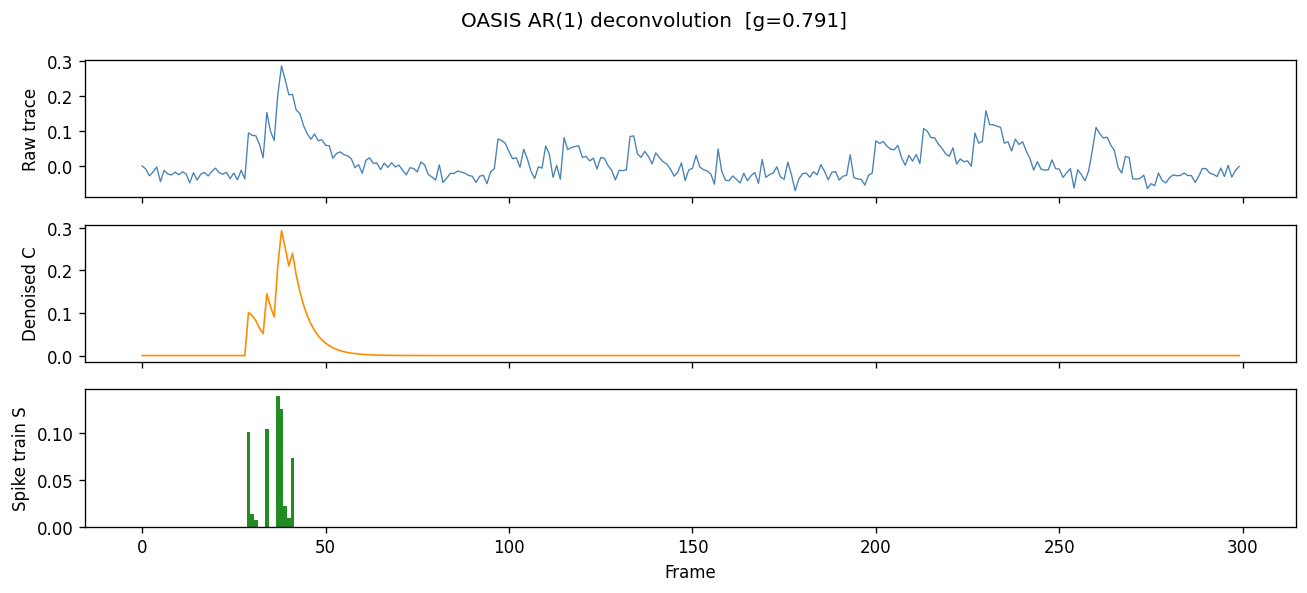

In [13]:
from minicnmfe.temporal import estimate_ar_params, deconvolve

trace_raw = C_raw_init[0]
g, sn = estimate_ar_params(trace_raw, p=1)
c_clean, s_train, baseline = deconvolve(trace_raw, g, sn)

print(f'Estimated g = {g[0]:.3f}   (true g = {data["ar_decay"]:.3f})')
print(f'Estimated sn = {sn:.3f}')

fig, axes = plt.subplots(3, 1, figsize=(11, 5), sharex=True)
axes[0].plot(trace_raw, lw=0.8, color='steelblue'); axes[0].set_ylabel('Raw trace')
axes[1].plot(c_clean,  lw=1.0, color='darkorange'); axes[1].set_ylabel('Denoised C')
axes[2].bar(np.arange(len(s_train)), s_train, width=1, color='forestgreen', linewidth=0)
axes[2].set_ylabel('Spike train S'); axes[2].set_xlabel('Frame')
plt.suptitle(f'OASIS AR(1) deconvolution  [g={g[0]:.3f}]')
plt.tight_layout(); plt.show()

In [ ]:
from minicnmfe.pipeline import CNMFe, CNMFeParams
from tests.test_pipeline import match_components

params = CNMFeParams(
    sigma=3.0,
    min_corr=0.8,
    min_pnr=6.0,
    n_iter_main=2,
    n_iter_temporal=2,
    mc_n_iter=1,
    spatial_max_thr=0.1,
    merge_thr_corr=0.85,
    merge_thr_overlap=0.5,
    global_ar=True,       # True = one g from pooled C_raw; False = per-neuron g
)

model = CNMFe(params).fit(movie, do_motion_correction=False)

print(f'\nExtracted {model.A.shape[1]} neurons (truth = {K})')
print(f'A   shape: {model.A.shape}   - sparse spatial footprints')
print(f'C   shape: {model.C.shape}      - OASIS-deconvolved (clean AR(1))')
print(f'YrA shape: {model.YrA.shape}      - residual; C + YrA is the noisy projection')
print(f'S   shape: {model.S.shape}      - spike trains')
print(f'g   list:  len={len(model.g)}   first AR coef = {model.g[0][0]:.3f}')

---
## 9. Two flavours of the calcium trace — and how they compare to the data

CNMFe exposes two related calcium traces for each neuron:

| Attribute | What it is | When to use |
|-----------|-----------|-------------|
| `model.C[k]` | OASIS-deconvolved trace — clean AR(1) shape | Spike-event detection, smooth amplitude features |
| `model.C[k] + model.YrA[k]` | Noisy *projected* trace — the data at that footprint with all *other* neurons subtracted | Shape-faithful comparisons: cross-correlating with a behavioural variable, regressing against an external reference, anywhere the OASIS shape constraint would distort the answer |

Below we compare both flavours against (a) ground truth and (b) the raw single-pixel trace at each neuron's centre. Same neuron, three viewpoints.

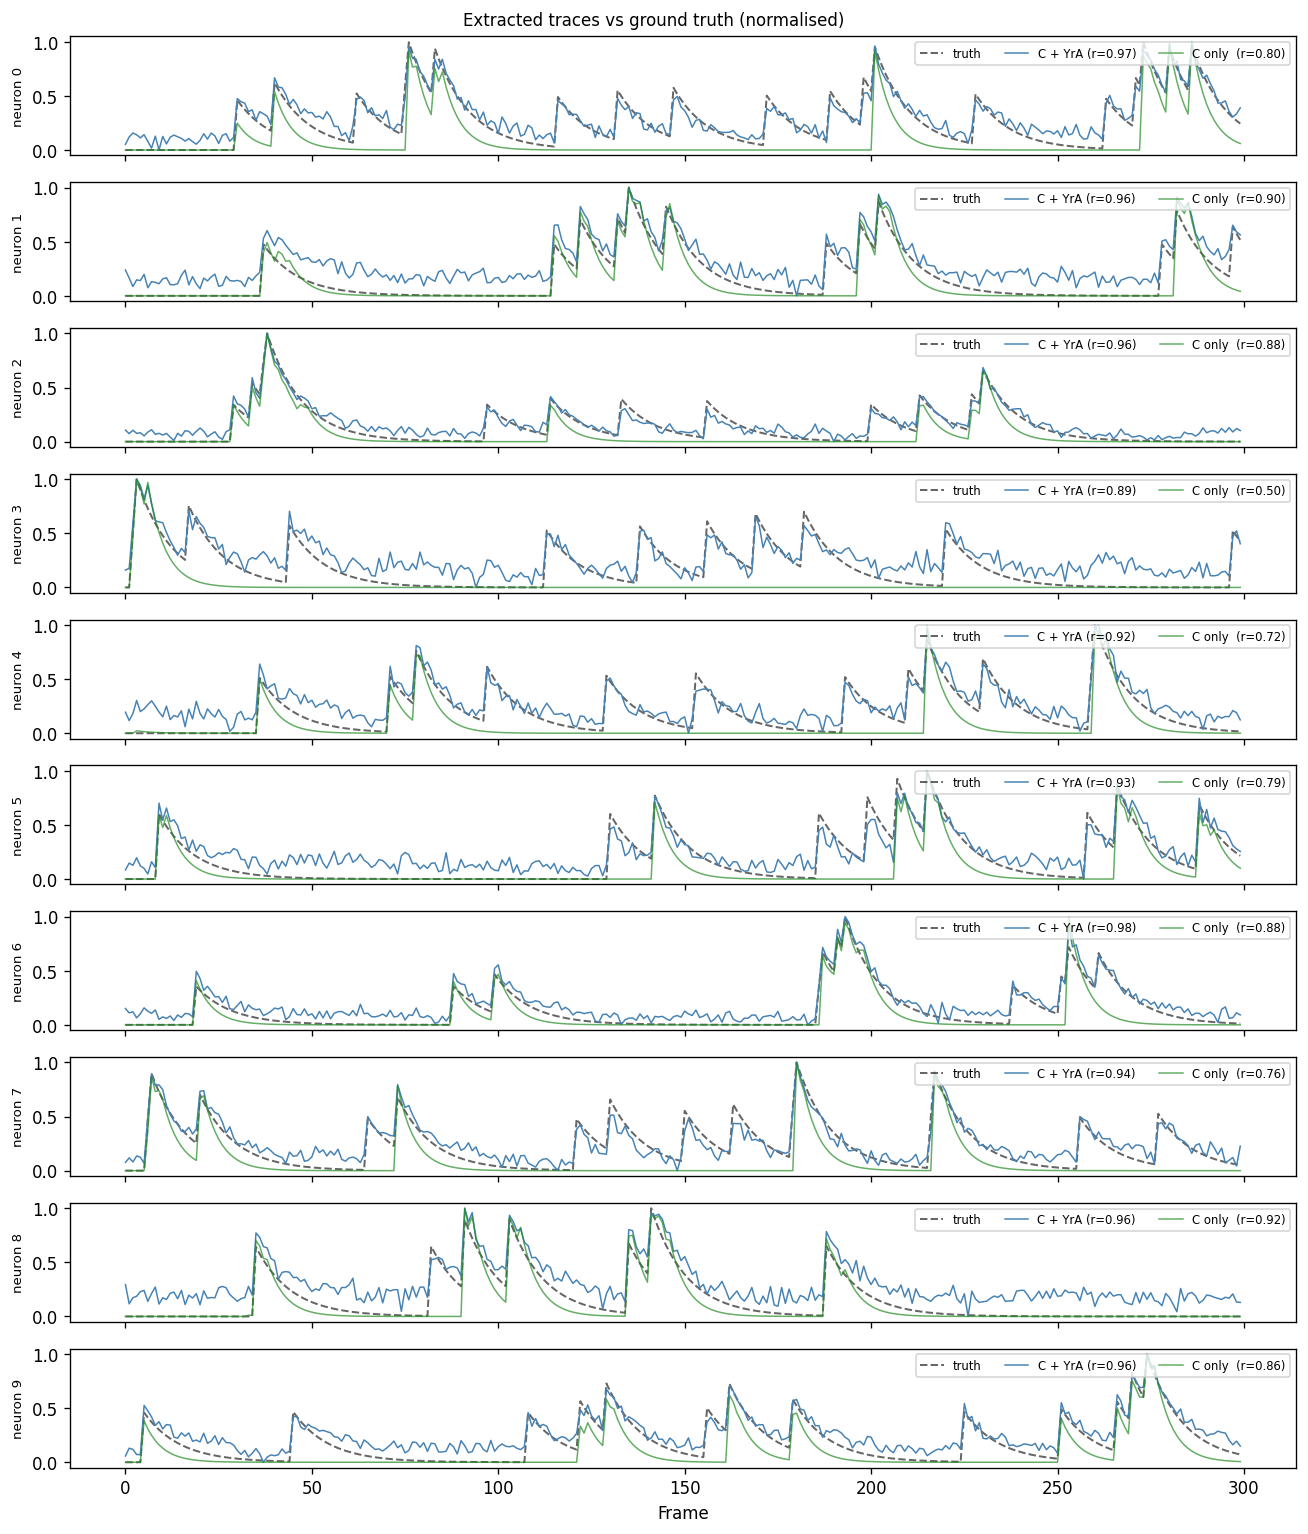

Mean Pearson r vs truth:  C only = 0.801,  C + YrA = 0.947


In [17]:
# --- (a) C and C + YrA vs ground truth -------------------------------------
n_rows = len(matches)
fig, axes = plt.subplots(n_rows, 1, figsize=(11, 1.3 * n_rows), sharex=True)
if n_rows == 1: axes = [axes]
for ax, (k_true, k_est, sc) in zip(axes, sorted(matches)):
    r_oasis = pearson(model.C[k_est], C_true[k_true])
    r_proj  = pearson(C_proj[k_est],  C_true[k_true])
    ax.plot(norm01(C_true[k_true]), lw=1.2, color='black', ls='--', alpha=0.6, label='truth')
    ax.plot(norm01(C_proj[k_est]),  lw=0.9, color='steelblue',
            label=f'C + YrA (r={r_proj:.2f})')
    ax.plot(norm01(model.C[k_est]), lw=0.9, color='forestgreen', alpha=0.7,
            label=f'C only  (r={r_oasis:.2f})')
    ax.set_ylabel(f'neuron {k_true}', fontsize=8)
    ax.legend(loc='upper right', fontsize=7, ncol=3)
axes[-1].set_xlabel('Frame')
plt.suptitle('Extracted traces vs ground truth (normalised)', fontsize=10)
plt.tight_layout(); plt.show()

rs_oasis = [pearson(model.C[ke], C_true[kt]) for kt, ke, _ in matches]
rs_proj  = [pearson(C_proj[ke],  C_true[kt]) for kt, ke, _ in matches]
print(f'Mean Pearson r vs truth:  C only = {np.mean(rs_oasis):.3f},  '
      f'C + YrA = {np.mean(rs_proj):.3f}')

---
## 10. Summary

| Step | What it does | Why |
|------|-------------|-----|
| Zarr I/O | Time-chunked random-access movie | No need to load the whole file |
| Motion correction | Rigid FFT-based alignment | Avoid smeared footprints |
| Center-surround PSF | Spatial bandpass | Suppress diffuse background |
| CORR / PNR | Where are the neurons? | Provides seeds |
| Ring background | Per-pixel ridge regression | Removes correlated 1p background |
| Greedy init | Iterative seed → extract → subtract | Robust: strongest neuron first |
| Spatial update | Per-pixel non-negative LASSO | Refine footprint boundaries |
| Temporal update + OASIS | Block CD + AR(1) deconvolution | Clean trace + spike train |
| Merging | Combine duplicate detections | Catches near-duplicates that survived init |

**Key parameters**

| Parameter | Effect | Typical |
|-----------|--------|---------|
| `sigma` | Neuron radius (px) | 2–5 |
| `min_corr` | Min CORR for a seed | 0.6–0.9 |
| `min_pnr` | Min PNR for a seed | 5–15 |
| `n_iter_main` | Refinement passes | 2–3 |
| `merge_thr_corr` | Min temporal r to merge | 0.75–0.95 |
| `merge_centre_dist_factor` | Centre-distance fallback for merging (× σ) | 1.5–2.5 |
| `spatial_max_thr` | Footprint cleanup threshold | 0.05–0.2 |

In [19]:
import time

demo_params = dict(sigma=3.0, min_corr=0.8, min_pnr=6.0,
                   n_iter_main=2, n_iter_temporal=2, mc_n_iter=1)

t0 = time.time()
serial_model = CNMFe(CNMFeParams(**demo_params, n_jobs=1)).fit(movie, do_motion_correction=False)
t_serial = time.time() - t0

t0 = time.time()
par_model = CNMFe(CNMFeParams(**demo_params, n_jobs=4)).fit(movie, do_motion_correction=False)
t_parallel = time.time() - t0

print()
print(f'Serial   (n_jobs=1):  {t_serial:5.2f}s   neurons = {serial_model.A.shape[1]}')
print(f'Parallel (n_jobs=4):  {t_parallel:5.2f}s   neurons = {par_model.A.shape[1]}')
print(f'Speedup: {t_serial / t_parallel:4.2f}x')
print()
print('On a 64x64x300 movie the per-frame work is small, so worker startup dominates.')
print('For real recordings (>= 256x256, T >= 1000) expect 3-6x speedup with n_jobs=-1.')

Estimating noise...
Computing CORR and PNR images...


Running greedy CORR-PNR initialization...


  Found 10 initial components.
Fitting ring-model background (radius=10.5px)...


Refinement iteration 1/2...
  Pre-merging duplicate seeds...
  Updating spatial footprints...


  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).


...

Refinement iteration 1/2...
  Pre-merging duplicate seeds...
  Updating spatial footprints...


  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).


Refinement iteration 2/2...
  Updating spatial footprints...


  Updating temporal traces...
  Merging correlated components...
  10 components (0 merged).


Final temporal update...
Done. Extracted 10 neurons.

Serial   (n_jobs=1):   6.93s   neurons = 10
Parallel (n_jobs=4):   8.73s   neurons = 10
Speedup: 0.79x

On a 64x64x300 movie the per-frame work is small, so worker startup dominates.
For real recordings (>= 256x256, T >= 1000) expect 3-6x speedup with n_jobs=-1.
